# **Pandas 이해 및 활용 - DataFrame 변형하기**

- 데이터프레임에서 범주형 컬럼을 기준으로 groupby 함수를 사용해서 그룹핑해 보도록 하겠습니다.
- 특히, 분류 모델일 경우, 타켓 변수를 groupby 함수를 활용하여 그룹화해서 특징들을 한눈에 보고 비교할수 있어 자주 사용하게 됩니다. 
- 또한, 엑셀에서 피봇테이블을 사용하듯이 판다스의 pivot_table 함수를 활용해서 피봇 테이블을 만들어 보겠습니다.
- 피봇테이블을 통해서, 새로인 인사트를 발견할수 있고, 새로운 데이터를 만들수 있어 퓨쳐 엔지니어링쪽에서 활용할수 있습니다. 
- 데이터프레임의 stack, unstack 함수를 사용해서 데이터프레임을 변경해 보도록 하겠습니다.
- 다소 어려운 여러가지 함수들이 나오고 있는데, 모를때는 매뉴얼이나 인터넷 검색으로 사용방법을 찾아 주시면 되고
- 실제 타이핑해 보면서 어떻게 동작하고 변경되는지 확인해 보도록 하겠습니다.

<br>

## __1. DataFrame group by 이해하기__


### <b>1-1. 데이터 묶기</b>

In [32]:
# 라이브러리 임포트
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

#### <b>1) 그룹화(groupby)</b>

  + 같은 값을 하나로 묶어 통계 또는 집계 결과를얻기위해 사용하는 것
  + 아래의 세 단계를 적용하여 데이터를 그룹화(groupping) / 특정한 col을 기준으로 데이터를 그룹핑 하여 통계에 활용하는 것
    - 데이터 분할(split) : 어떠한 기준을 바탕으로 데이터를 나누는 일
    - operation 적용(applying) : 각 그룹에 어떤 함수를 독립적으로 적용시키는 일
    - 데이터 병합(cobine) : 적용되어 나온 결과들을 통합하는 일
  + 데이터 분석에 있어 사용빈도가 높음
  + groupby의 결과는 dictionary형태임


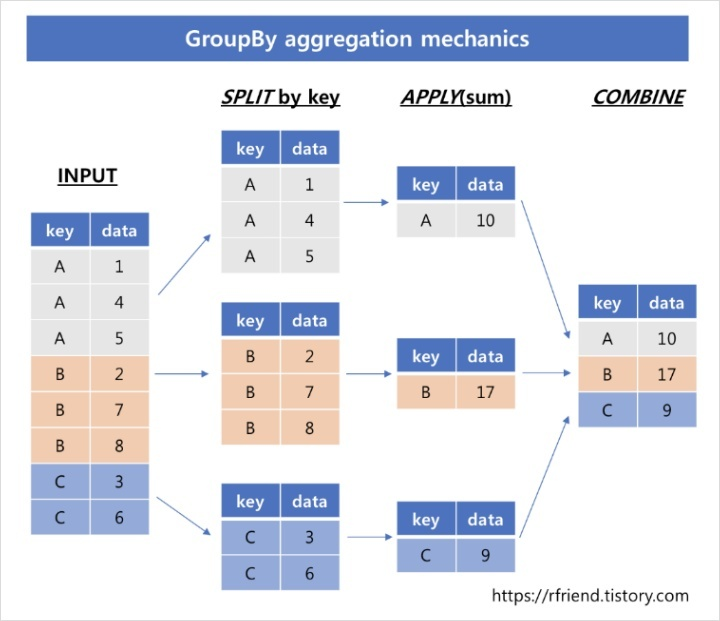
- 출처 : https://rfriend.tistory.com/383
<br>
<br>

In [38]:
# sc_cust_info_txn_v1.5.csv 파일 읽고 cust 데이터프레임에 저장하기
cust = pd.read_csv('../sc_cust_info_txn_v1.5.csv')
cust

,base_ym,dpro_tgt_perd_val,cust_ctg_type,cust_class,sex_type,age,efct_svc_count,dt_stop_yn,npay_yn,r3m_avg_bill_amt,r3m_A_avg_arpu_amt,r3m_B_avg_arpu_amt,r6m_A_avg_arpu_amt,r6m_B_avg_arpu_amt,termination_yn
0,202006,20200630,10001,C,F,28,0,N,N,2640.0000,792.000000,1584.0000,0.0,0.0000,Y
1,202006,20200630,10001,_,_,_,1,N,N,300.0000,90.000000,180.0000,0.0,0.0000,Y
2,202006,20200630,10001,E,F,24,1,N,N,16840.0000,2526.000000,6983.0000,0.0,6981.0000,N
3,202006,20200630,10001,F,F,32,1,N,N,15544.7334,2331.710010,6750.4666,0.0,6508.8000,N
4,202006,20200630,10001,D,M,18,1,N,N,4700.0000,0.000000,4502.0000,0.0,4507.7000,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9925,202006,20200630,10001,C,F,15,1,N,Y,1296.0999,194.414985,643.1001,0.0,852.5499,N
9926,202006,20200630,10001,G,M,12,1,N,N,13799.6666,2069.949990,10605.9266,0.0,10603.9266,N
9927,202006,20200630,10005,C,_,_,1,N,N,1396.2000,1206.000000,0.0000,1212.0,0.0000,N
9928,202006,20200630,10001,C,F,40,0,N,N,3140.0000,942.000000,1884.0000,0.0,0.0000,Y


> ##### __1-1) cust 데이터프레임에서 성별('sex_type') 컬럼으로 그룹화하기__
> - 성별('sex_type') 컬럼은 'M'과 'F' 값들로 구성된 범주형 컬럼
> - 그룹핑할려는 컬럼이 범주형이어야 제대로 그룹을 나눌수 있음을 기억

In [39]:
# 그룹핑하려면 groupby 함수를 활용하면 되고, groupby 함수 안에 그룹으로 나누고자 하는 컬럼명 'sex_type'을 넣으면 됩니다.
# 그룹핑 결과를 gender_group 변수에 저장합니다.

gender_group = cust.groupby('sex_type')
gender_group

In [40]:
# groups를 활용하여 그룹의 속성을 살펴 봅니다.
# 결과를 보니 딕셔너리 형태 , Key와 Value로 구성된 형태가 보입니다.
# 'F'를 key로 해서 'sex_type' 컬럼의 값이 'F'인 인덱스 번호가 모인 리스트가 보이며, 
# 'M'을 key로 해서 'sex_type' 컬럼의 값이 'M'인 인덱스번호가 모인 리스트가 보입니다. 
# 'sex_type' 컬럼을 기준으로 'M'과 'F'로 잘 그룹화 된것을 확인할수 있습니다.

gender_group.groups

{'F': [0, 2, 3, 5, 7, 9, 12, 13, 14, 16, 17, 19, 20, 21, 24, 25, 26, 40, 41, 43, 46, 47, 49, 51, 52, 55, 65, 69, 73, 75, 77, 79, 80, 81, 82, 85, 86, 90, 91, 93, 94, 95, 101, 105, 106, 111, 112, 116, 119, 120, 121, 127, 130, 131, 134, 135, 136, 137, 138, 142, 143, 147, 148, 149, 151, 152, 155, 156, 157, 159, 163, 164, 166, 167, 169, 173, 174, 176, 177, 181, 184, 190, 191, 193, 195, 197, 205, 206, 208, 210, 211, 213, 215, 216, 218, 221, 225, 230, 234, 235, ...], 'M': [4, 6, 8, 11, 15, 18, 22, 23, 27, 28, 29, 30, 31, 32, 33, 34, 36, 37, 38, 39, 42, 44, 45, 48, 50, 53, 54, 56, 57, 58, 59, 60, 61, 63, 64, 67, 68, 70, 74, 76, 78, 84, 87, 88, 89, 96, 97, 98, 99, 100, 103, 104, 107, 108, 109, 110, 113, 115, 117, 122, 123, 124, 125, 126, 128, 132, 133, 139, 140, 141, 144, 145, 146, 150, 153, 154, 158, 160, 161, 162, 168, 170, 171, 172, 175, 178, 179, 180, 183, 185, 186, 187, 188, 189, 192, 194, 198, 199, 200, 201, ...], '_': [1, 10, 35, 62, 66, 71, 72, 83, 92, 102, 114, 118, 129, 165, 182, 196,

>##### __1-2) groupby 내부 함수 활용하기__
 - 그룹 데이터에 적용 가능한 통계 함수(NaN은 제외하여 연산)
 - count : 데이터 개수
 - size : 집단별 크기
 - sum  : 데이터의 합
 - mean, std, var : 평균, 표준편차, 분산
 - min, max : 최소, 최대값

In [41]:
# count 함수 확인. 
# 화면에 보이는 결과는 데이터프레임 형태

gender_group.count()

,base_ym,dpro_tgt_perd_val,cust_ctg_type,cust_class,age,efct_svc_count,dt_stop_yn,npay_yn,r3m_avg_bill_amt,r3m_A_avg_arpu_amt,r3m_B_avg_arpu_amt,r6m_A_avg_arpu_amt,r6m_B_avg_arpu_amt,termination_yn
sex_type,,,,,,,,,,,,,,
F,4251,4251,4251,4251,4251,4251,4251,4251,4251,4251,4251,4251,4251,4251
M,4998,4998,4998,4998,4998,4998,4998,4998,4998,4998,4998,4998,4998,4998
_,681,681,681,681,681,681,681,681,681,681,681,681,681,681


In [42]:
# mean 함수 확인 : 에러 발생 > 문자열 데이터를 평균을 낼수가 없기에
gender_group.mean()

TypeError: dtype 'str' does not support operation 'mean'

In [ ]:
# 평균을 보고자 하는 숫자열 컬럼들을 나열하고 거기에 대해서 평균을 구하면 된다. 
# 먼저, cust 데이터프레임의 타입 정보를 확인해 보면 각 컬럼이 문자열 타입과 숫자형 타입인지 알수 있다. 

cust.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9930 entries, 0 to 9929
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   base_ym             9930 non-null   int64  
 1   dpro_tgt_perd_val   9930 non-null   int64  
 2   cust_ctg_type       9930 non-null   int64  
 3   cust_class          9930 non-null   object 
 4   sex_type            9930 non-null   object 
 5   age                 9930 non-null   object 
 6   efct_svc_count      9930 non-null   int64  
 7   dt_stop_yn          9930 non-null   object 
 8   npay_yn             9930 non-null   object 
 9   r3m_avg_bill_amt    9930 non-null   float64
 10  r3m_A_avg_arpu_amt  9930 non-null   float64
 11  r3m_B_avg_arpu_amt  9930 non-null   float64
 12  r6m_A_avg_arpu_amt  9930 non-null   float64
 13  r6m_B_avg_arpu_amt  9930 non-null   float64
 14  termination_yn      9930 non-null   object 
dtypes: float64(5), int64(4), object(6)
memory usage: 1.1+ M

In [ ]:
# 위의 정보를 바탕으로 select_dtypes() 함수를 활용해서 숫자형 컬럼들을 추출해 보자.
cust.select_dtypes([ 'int64', 'float64']) 

,base_ym,dpro_tgt_perd_val,cust_ctg_type,efct_svc_count,r3m_avg_bill_amt,r3m_A_avg_arpu_amt,r3m_B_avg_arpu_amt,r6m_A_avg_arpu_amt,r6m_B_avg_arpu_amt
0,202006,20200630,10001,0,2640.0000,792.000000,1584.0000,0.0,0.0000
1,202006,20200630,10001,1,300.0000,90.000000,180.0000,0.0,0.0000
2,202006,20200630,10001,1,16840.0000,2526.000000,6983.0000,0.0,6981.0000
3,202006,20200630,10001,1,15544.7334,2331.710010,6750.4666,0.0,6508.8000
4,202006,20200630,10001,1,4700.0000,0.000000,4502.0000,0.0,4507.7000
...,...,...,...,...,...,...,...,...,...
9925,202006,20200630,10001,1,1296.0999,194.414985,643.1001,0.0,852.5499
9926,202006,20200630,10001,1,13799.6666,2069.949990,10605.9266,0.0,10603.9266
9927,202006,20200630,10005,1,1396.2000,1206.000000,0.0000,1212.0,0.0000
9928,202006,20200630,10001,0,3140.0000,942.000000,1884.0000,0.0,0.0000


In [ ]:
# 위의 정보를 바탕으로 select_dtypes() 함수를 활용해서 숫자형 컬럼들을 추출해 보자.

col = cust.select_dtypes([ 'int64', 'float64']).columns
col

Index(['base_ym', 'dpro_tgt_perd_val', 'cust_ctg_type', 'efct_svc_count',
       'r3m_avg_bill_amt', 'r3m_A_avg_arpu_amt', 'r3m_B_avg_arpu_amt',
       'r6m_A_avg_arpu_amt', 'r6m_B_avg_arpu_amt'],
      dtype='str')

In [ ]:
# gender_group 그룹화 변수에 위의 숫자형 변수 2개를 골라 넣고 평균을 구해보자. 
gender_group[ [ 'r3m_avg_bill_amt', 'r3m_A_avg_arpu_amt' ] ].mean()

,r3m_avg_bill_amt,r3m_A_avg_arpu_amt
sex_type,,
F,9580.926307,1570.372299
M,9839.707339,1778.988878
_,40297.790077,4809.827390


In [ ]:
# gender_group 그룹화 변수에 위의 모든 숫자형 변수 넣고 평균을 구해보자. 
gender_group[ col ].mean()

,base_ym,dpro_tgt_perd_val,cust_ctg_type,efct_svc_count,r3m_avg_bill_amt,r3m_A_avg_arpu_amt,r3m_B_avg_arpu_amt,r6m_A_avg_arpu_amt,r6m_B_avg_arpu_amt
sex_type,,,,,,,,,
F,202006.0,20200630.0,10001.001882,1.098800,9580.926307,1570.372299,5283.876950,452.780488,4961.455810
M,202006.0,20200630.0,10001.004802,1.204882,9839.707339,1778.988878,5342.748791,641.426866,4851.027884
_,202006.0,20200630.0,10006.389134,6.462555,40297.790077,4809.827390,21057.412985,4854.788244,864.386867


In [ ]:
# max값 확인하기 : 결과는 데이터프레임 타입인걸 확인할수 있다. 
gender_group.max()

,base_ym,dpro_tgt_perd_val,cust_ctg_type,cust_class,age,efct_svc_count,dt_stop_yn,npay_yn,r3m_avg_bill_amt,r3m_A_avg_arpu_amt,r3m_B_avg_arpu_amt,r6m_A_avg_arpu_amt,r6m_B_avg_arpu_amt,termination_yn
sex_type,,,,,,,,,,,,,,
F,202006,20200630,10005,_,_,9,Y,Y,7.979563e+04,5.500240e+04,5.710153e+04,2.302815e+04,48787.2333,Y
M,202006,20200630,10005,_,_,14,Y,Y,1.447397e+05,1.315815e+05,6.583656e+04,2.749282e+04,64947.0920,Y
_,202006,20200630,10010,_,_,905,Y,Y,1.281568e+07,1.188998e+06,7.689409e+06,1.208498e+06,18796.6266,Y


In [ ]:
# gender_group.max()의 결과가 데이터프레임이므로 데이터프레임에 원하는 컬럼명을 넣어 조회할수 있다. 
gender_group.max()[ ['r3m_avg_bill_amt', 'r3m_A_avg_arpu_amt'] ] 

,r3m_avg_bill_amt,r3m_A_avg_arpu_amt
sex_type,,
F,7.979563e+04,5.500240e+04
M,1.447397e+05,1.315815e+05
_,1.281568e+07,1.188998e+06


In [ ]:
# gender_group 그룹화 변수의 평균에 대해 특정 col만 보는 경우 에러가 발생한다. 
# 왜냐하면 문자열 타입의 컬럼에 대해 평균을 구할수 없기에 

gender_group.mean()[ ['r3m_avg_bill_amt', 'r3m_A_avg_arpu_amt'] ]

TypeError: dtype 'str' does not support operation 'mean'

In [ ]:
# gender_group 그룹화 변수의 평균에 대해 특정 col만 보는 경우 에러가 발생한다. 
# 에러가 발생되지 않으려면 그룹화변수에서 숫자형 컬럼만을 먼저 선택하고 평균을 구하면 된다.  

gender_group[ ['r3m_avg_bill_amt', 'r3m_A_avg_arpu_amt'] ].mean()

,r3m_avg_bill_amt,r3m_A_avg_arpu_amt
sex_type,,
F,9580.926307,1570.372299
M,9839.707339,1778.988878
_,40297.790077,4809.827390


> ##### __1-3) 인덱스 설정(groupby) 후 데이터 추출하기__
- 성별 r3m_avg_bill_amt의 평균

In [ ]:
# 성별 r3m_avg_bill_amt의 평균 확인하기
gender_group[ ['r3m_avg_bill_amt'] ].mean()

,r3m_avg_bill_amt
sex_type,
F,9580.926307
M,9839.707339
_,40297.790077


In [ ]:
# 성별 r3m_avg_bill_amt의 평균 확인하기(위와 같다)
cust.groupby('sex_type')[ ['r3m_avg_bill_amt'] ].mean()

,r3m_avg_bill_amt
sex_type,
F,9580.926307
M,9839.707339
_,40297.790077


>##### __1-4) 복수 columns을 기준으로 Groupping 하기__
>- groupby에 column 리스트를 전달할 수 있고 복수개의 전달도 가능함
>- 통계함수를 적용한 결과는 multiindex를 갖는 DataFrame

In [ ]:
# cust_class 와 sex_type으로 index를 정하고 이에따른 r3m_avg_bill_amt의 평균을 구하기
cust.groupby( ['cust_class', 'sex_type'] )[ ['r3m_avg_bill_amt'] ].mean()

r3m_avg_bill_amt
cust_class sex_type                  
C          F              3804.342244
           M              3155.385796
           _              4719.075980
D          F              7848.842709
           M              7774.098954
           _              8419.764574
E          F             11257.301485
           M             11158.736812
           _             12208.980550
F          F             14913.105272
           M             15013.379957
           _             16231.437767
G          F             16538.595017
           M             16847.160637
           _             20180.014811
H          F             20154.938768
           M             21052.154088
_          F              4304.582332
           M              4728.388010
           _             65268.733884

In [ ]:
# 위와 동일하게 groupby한 이후에 평균 구하기

multi_group = cust.groupby( ['cust_class', 'sex_type'] )
multi_group[ ['r3m_avg_bill_amt'] ].mean()

r3m_avg_bill_amt
cust_class sex_type                  
C          F              3804.342244
           M              3155.385796
           _              4719.075980
D          F              7848.842709
           M              7774.098954
           _              8419.764574
E          F             11257.301485
           M             11158.736812
           _             12208.980550
F          F             14913.105272
           M             15013.379957
           _             16231.437767
G          F             16538.595017
           M             16847.160637
           _             20180.014811
H          F             20154.938768
           M             21052.154088
_          F              4304.582332
           M              4728.388010
           _             65268.733884

In [ ]:
# 멀티인덱스에서 loc 함수를 사용하여 원하는 row 선택 해보기
cust.groupby(['cust_class', 'sex_type'])[ ['r3m_avg_bill_amt'] ].mean().loc[ [("C","M"), ("D","M")] ]

,,r3m_avg_bill_amt
cust_class,sex_type,
C,M,3155.385796
D,M,7774.098954


> ##### __1-5) index를 이용한 group by__
> - index가 있는 경우, groupby 함수에 level 사용 가능
> - level은 index의 depth를 의미하며, 가장 왼쪽부터 0부터 증가
> - **set_index** 함수
>    - column 데이터를 index 레벨로 변경하는 경우 사용
>    - 기존 인덱스를 제거하고 데이터 컬럼 중 하나를 인덱스로 설정
> - **reset_index** 함수 
>    - 0부터 시작하는 새로운 인덱스 생성하여 인덱스 초기화 
>    - 기존 인덱스는 데이터 컬럼으로 추가

In [ ]:
# cust DataFrame 다시 한번 확인 합니다.
cust.head()

,base_ym,dpro_tgt_perd_val,cust_ctg_type,cust_class,sex_type,age,efct_svc_count,dt_stop_yn,npay_yn,r3m_avg_bill_amt,r3m_A_avg_arpu_amt,r3m_B_avg_arpu_amt,r6m_A_avg_arpu_amt,r6m_B_avg_arpu_amt,termination_yn
0,202006,20200630,10001,C,F,28,0,N,N,2640.0000,792.00000,1584.0000,0.0,0.0,Y
1,202006,20200630,10001,_,_,_,1,N,N,300.0000,90.00000,180.0000,0.0,0.0,Y
2,202006,20200630,10001,E,F,24,1,N,N,16840.0000,2526.00000,6983.0000,0.0,6981.0,N
3,202006,20200630,10001,F,F,32,1,N,N,15544.7334,2331.71001,6750.4666,0.0,6508.8,N
4,202006,20200630,10001,D,M,18,1,N,N,4700.0000,0.00000,4502.0000,0.0,4507.7,N


> ##### __1-6) MultiIndex를 이용한 groupping__

In [ ]:
# set_index() 함수를 활용해서 컬럼을 index로 만들기
# cust_class 컬럼을 인덱스로 만들어 보자. 
# 화면에 출력되며, 해당 내용이 cust 데이터프레임에 저장되는것은 아니다. 

cust.set_index( ['cust_class'] )

,base_ym,dpro_tgt_perd_val,cust_ctg_type,sex_type,age,efct_svc_count,dt_stop_yn,npay_yn,r3m_avg_bill_amt,r3m_A_avg_arpu_amt,r3m_B_avg_arpu_amt,r6m_A_avg_arpu_amt,r6m_B_avg_arpu_amt,termination_yn
cust_class,,,,,,,,,,,,,,
C,202006,20200630,10001,F,28,0,N,N,2640.0000,792.000000,1584.0000,0.0,0.0000,Y
_,202006,20200630,10001,_,_,1,N,N,300.0000,90.000000,180.0000,0.0,0.0000,Y
E,202006,20200630,10001,F,24,1,N,N,16840.0000,2526.000000,6983.0000,0.0,6981.0000,N
F,202006,20200630,10001,F,32,1,N,N,15544.7334,2331.710010,6750.4666,0.0,6508.8000,N
D,202006,20200630,10001,M,18,1,N,N,4700.0000,0.000000,4502.0000,0.0,4507.7000,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C,202006,20200630,10001,F,15,1,N,Y,1296.0999,194.414985,643.1001,0.0,852.5499,N
G,202006,20200630,10001,M,12,1,N,N,13799.6666,2069.949990,10605.9266,0.0,10603.9266,N
C,202006,20200630,10005,_,_,1,N,N,1396.2000,1206.000000,0.0000,1212.0,0.0000,N


In [ ]:
# set_index() 함수를 활용해서 멀티 인덱스 만들어 보기
# 이번에는 'cust_class','sex_type' 2개의 컬럼을 인덱스로 만들어 봅시다.

multi_cust = cust.set_index( ['cust_class','sex_type'] )
multi_cust

,,base_ym,dpro_tgt_perd_val,cust_ctg_type,age,efct_svc_count,dt_stop_yn,npay_yn,r3m_avg_bill_amt,r3m_A_avg_arpu_amt,r3m_B_avg_arpu_amt,r6m_A_avg_arpu_amt,r6m_B_avg_arpu_amt,termination_yn
cust_class,sex_type,,,,,,,,,,,,,
C,F,202006,20200630,10001,28,0,N,N,2640.0000,792.000000,1584.0000,0.0,0.0000,Y
_,_,202006,20200630,10001,_,1,N,N,300.0000,90.000000,180.0000,0.0,0.0000,Y
E,F,202006,20200630,10001,24,1,N,N,16840.0000,2526.000000,6983.0000,0.0,6981.0000,N
F,F,202006,20200630,10001,32,1,N,N,15544.7334,2331.710010,6750.4666,0.0,6508.8000,N
D,M,202006,20200630,10001,18,1,N,N,4700.0000,0.000000,4502.0000,0.0,4507.7000,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C,F,202006,20200630,10001,15,1,N,Y,1296.0999,194.414985,643.1001,0.0,852.5499,N
G,M,202006,20200630,10001,12,1,N,N,13799.6666,2069.949990,10605.9266,0.0,10603.9266,N
C,_,202006,20200630,10005,_,1,N,N,1396.2000,1206.000000,0.0000,1212.0,0.0000,N


In [ ]:
# reset_index 함수를 활용해 봅시다.  (set_index <-> reset_index)  
# 즉, multi_cust 데이터프레임은 2개 컬럼(cust_class','sex_type')을 멀티 인덱스를 사용하는데
# 해당 multi_cust 데이터프레임에 reset_index 함수를 사용하면, 0부터 시작하는 새로운 인덱스가 생성되고
# 기존 멀티 인덱스는 컬럼으로 이동된다. 확인해 봅시다.
# 단, reset_index 적용되어 화면에 출력되어, 해당 내용이 nulti_cust 데이터프레임에 저장되지 않는다. 

multi_cust.reset_index()

,cust_class,sex_type,base_ym,dpro_tgt_perd_val,cust_ctg_type,age,efct_svc_count,dt_stop_yn,npay_yn,r3m_avg_bill_amt,r3m_A_avg_arpu_amt,r3m_B_avg_arpu_amt,r6m_A_avg_arpu_amt,r6m_B_avg_arpu_amt,termination_yn
0,C,F,202006,20200630,10001,28,0,N,N,2640.0000,792.000000,1584.0000,0.0,0.0000,Y
1,_,_,202006,20200630,10001,_,1,N,N,300.0000,90.000000,180.0000,0.0,0.0000,Y
2,E,F,202006,20200630,10001,24,1,N,N,16840.0000,2526.000000,6983.0000,0.0,6981.0000,N
3,F,F,202006,20200630,10001,32,1,N,N,15544.7334,2331.710010,6750.4666,0.0,6508.8000,N
4,D,M,202006,20200630,10001,18,1,N,N,4700.0000,0.000000,4502.0000,0.0,4507.7000,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9925,C,F,202006,20200630,10001,15,1,N,Y,1296.0999,194.414985,643.1001,0.0,852.5499,N
9926,G,M,202006,20200630,10001,12,1,N,N,13799.6666,2069.949990,10605.9266,0.0,10603.9266,N
9927,C,_,202006,20200630,10005,_,1,N,N,1396.2000,1206.000000,0.0000,1212.0,0.0000,N
9928,C,F,202006,20200630,10001,40,0,N,N,3140.0000,942.000000,1884.0000,0.0,0.0000,Y


In [ ]:
# multi_cust 데이터프레임 다시 보기 
# 멀티인덱스 cust_class','sex_type' 확인할수 있습니다.

multi_cust.head(3)

,,base_ym,dpro_tgt_perd_val,cust_ctg_type,age,efct_svc_count,dt_stop_yn,npay_yn,r3m_avg_bill_amt,r3m_A_avg_arpu_amt,r3m_B_avg_arpu_amt,r6m_A_avg_arpu_amt,r6m_B_avg_arpu_amt,termination_yn
cust_class,sex_type,,,,,,,,,,,,,
C,F,202006,20200630,10001,28,0,N,N,2640.0,792.0,1584.0,0.0,0.0,Y
_,_,202006,20200630,10001,_,1,N,N,300.0,90.0,180.0,0.0,0.0,Y
E,F,202006,20200630,10001,24,1,N,N,16840.0,2526.0,6983.0,0.0,6981.0,N


In [ ]:
# 컬럼으로 그룹핑하는게 아니라 인덱스로 그룹핑해 보기
# multi_cust 데이터 프레임에서 cust_class 인덱스를 가지고 그룹핑 해 보겠습니다. 
# sex_type 인덱스는 없어짐

multi_cust.groupby('cust_class').count().head()

,base_ym,dpro_tgt_perd_val,cust_ctg_type,age,efct_svc_count,dt_stop_yn,npay_yn,r3m_avg_bill_amt,r3m_A_avg_arpu_amt,r3m_B_avg_arpu_amt,r6m_A_avg_arpu_amt,r6m_B_avg_arpu_amt,termination_yn
cust_class,,,,,,,,,,,,,
C,2092,2092,2092,2092,2092,2092,2092,2092,2092,2092,2092,2092,2092
D,2250,2250,2250,2250,2250,2250,2250,2250,2250,2250,2250,2250,2250
E,1269,1269,1269,1269,1269,1269,1269,1269,1269,1269,1269,1269,1269
F,726,726,726,726,726,726,726,726,726,726,726,726,726
G,2051,2051,2051,2051,2051,2051,2051,2051,2051,2051,2051,2051,2051


In [ ]:
# 컬럼으로 그룹핑하는게 아니라 인덱스로 그룹핑해 보기
# multi_cust 데이터 프레임에서 sex_type 인덱스를 가지고 그룹핑 해 보겠습니다.
# 앞쪽의 cust_class 인덱스는 사라짐.

multi_cust.groupby('sex_type').count()

,base_ym,dpro_tgt_perd_val,cust_ctg_type,age,efct_svc_count,dt_stop_yn,npay_yn,r3m_avg_bill_amt,r3m_A_avg_arpu_amt,r3m_B_avg_arpu_amt,r6m_A_avg_arpu_amt,r6m_B_avg_arpu_amt,termination_yn
sex_type,,,,,,,,,,,,,
F,4251,4251,4251,4251,4251,4251,4251,4251,4251,4251,4251,4251,4251
M,4998,4998,4998,4998,4998,4998,4998,4998,4998,4998,4998,4998,4998
_,681,681,681,681,681,681,681,681,681,681,681,681,681


In [ ]:
# 아래와 같이 할수도 있습니다. 
cust.set_index( ['cust_class','sex_type'] ).groupby( ['cust_class','sex_type'] ).count().head(9)

base_ym  dpro_tgt_perd_val  cust_ctg_type   age  \
cust_class sex_type                                                    
C          F             849                849            849   849   
           M            1064               1064           1064  1064   
           _             179                179            179   179   
D          F            1097               1097           1097  1097   
           M            1087               1087           1087  1087   
           _              66                 66             66    66   
E          F             639                639            639   639   
           M             606                606            606   606   
           _              24                 24             24    24   

                     efct_svc_count  dt_stop_yn  npay_yn  r3m_avg_bill_amt  \
cust_class sex_type                                                          
C          F                    849         849      849               849   
           M                   1064        1064     1064              1064   
           _                    179         179      179               179   
D          F                   1097        1097     1097              1097   
           M                   1087        1087     1087              1087   
           _                     66          66       66                66   
E          F                    639         639      639               639   
           M                    606         606      606               606   
           _                     24          24       24                24   

                     r3m_A_avg_arpu_amt  r3m_B_avg_arpu_amt  \
cust_class sex_type                                           
C          F                        849                 849   
           M                       1064                1064   
           _                        179                 179   
D          F                       1097                1097   
           M                       1087                1087   
           _                         66                  66   
E          F                        639                 639   
           M                        606                 606   
           _                         24                  24   

                     r6m_A_avg_arpu_amt  r6m_B_avg_arpu_amt  termination_yn  
cust_class sex_type                                                          
C          F                        849                 849             849  
           M                       1064                1064            1064  
           _                        179                 179             179  
D          F                       1097                1097            1097  
           M                       1087                1087            1087  
           _                         66                  66              66  
E          F                        639                 639             639  
           M                        606                 606             606  
           _                         24                  24              24

> ##### __1-7) aggregate(집계) 함수 사용하기__
> groupby 결과에 집계함수를 적용하여 그룹별(count, mean, max등) 데이터 확인 가능. 단, mean 함수 사용시 에러 안나게 주의 필요

In [ ]:
# 이번에는 aggregate() 함수를 사용해서 그룹별로 평균 집계연산 해 보겠습니다.
cust.set_index( ['cust_class','sex_type'] ).groupby( ['cust_class','sex_type'] ).aggregate( ['count'] ).head(9)

base_ym dpro_tgt_perd_val cust_ctg_type   age  \
                      count             count         count count   
cust_class sex_type                                                 
C          F            849               849           849   849   
           M           1064              1064          1064  1064   
           _            179               179           179   179   
D          F           1097              1097          1097  1097   
           M           1087              1087          1087  1087   
           _             66                66            66    66   
E          F            639               639           639   639   
           M            606               606           606   606   
           _             24                24            24    24   

                    efct_svc_count dt_stop_yn npay_yn r3m_avg_bill_amt  \
                             count      count   count            count   
cust_class sex_type                                                      
C          F                   849        849     849              849   
           M                  1064       1064    1064             1064   
           _                   179        179     179              179   
D          F                  1097       1097    1097             1097   
           M                  1087       1087    1087             1087   
           _                    66         66      66               66   
E          F                   639        639     639              639   
           M                   606        606     606              606   
           _                    24         24      24               24   

                    r3m_A_avg_arpu_amt r3m_B_avg_arpu_amt r6m_A_avg_arpu_amt  \
                                 count              count              count   
cust_class sex_type                                                            
C          F                       849                849                849   
           M                      1064               1064               1064   
           _                       179                179                179   
D          F                      1097               1097               1097   
           M                      1087               1087               1087   
           _                        66                 66                 66   
E          F                       639                639                639   
           M                       606                606                606   
           _                        24                 24                 24   

                    r6m_B_avg_arpu_amt termination_yn  
                                 count          count  
cust_class sex_type                                    
C          F                       849            849  
           M                      1064           1064  
           _                       179            179  
D          F                      1097           1097  
           M                      1087           1087  
           _                        66             66  
E          F                       639            639  
           M                       606            606  
           _                        24             24

In [ ]:
# 이번에는 aggregate() 함수를 사용해서 그룹별로 평균,최대 집계연산 해 보겠습니다.
cust.set_index( ['cust_class','sex_type'] ).groupby( ['cust_class','sex_type'] ).aggregate( ['min', 'max'] ).head(9)

base_ym         dpro_tgt_perd_val           cust_ctg_type  \
                        min     max               min       max           min   
cust_class sex_type                                                             
C          F         202006  202006          20200630  20200630         10001   
           M         202006  202006          20200630  20200630         10001   
           _         202006  202006          20200630  20200630         10001   
D          F         202006  202006          20200630  20200630         10001   
           M         202006  202006          20200630  20200630         10001   
           _         202006  202006          20200630  20200630         10005   
E          F         202006  202006          20200630  20200630         10001   
           M         202006  202006          20200630  20200630         10001   
           _         202006  202006          20200630  20200630         10005   

                           age     efct_svc_count      ... r3m_A_avg_arpu_amt  \
                       max min max            min max  ...                min   
cust_class sex_type                                    ...                      
C          F         10005  10  99              0   3  ...                0.0   
           M         10005  10  95              0   5  ...                0.0   
           _         10005   _   _              0   5  ...               90.0   
D          F         10005  10  91              0   6  ...                0.0   
           M         10005  10   _              0   5  ...                0.0   
           _         10005   _   _              0   5  ...              284.7   
E          F         10001  12   _              0   6  ...                0.0   
           M         10001  14  92              0   7  ...                0.0   
           _         10005   _   _              0   5  ...              519.0   

                                 r3m_B_avg_arpu_amt               \
                             max                min          max   
cust_class sex_type                                                
C          F          48101.6216                0.0  14434.01600   
           M          14774.7336                0.0  13909.40000   
           _          12389.3334                0.0  13760.71998   
D          F          16653.6667                0.0  14382.00000   
           M         131581.5333                0.0  19255.69998   
           _          18686.9650                0.0  19397.80002   
E          F          16373.3334                0.0  17532.89170   
           M          37972.7998                0.0  43474.32550   
           _           8696.0666                0.0   9865.06002   

                    r6m_A_avg_arpu_amt             r6m_B_avg_arpu_amt  \
                                   min         max                min   
cust_class sex_type                                                     
C          F                       0.0  10316.0334                0.0   
           M                       0.0   9689.3332                0.0   
           _                       0.0  19648.5002                0.0   
D          F                       0.0   8964.5224                0.0   
           M                       0.0  27492.8165                0.0   
           _                       0.0  10242.7268                0.0   
E          F                       0.0  13069.3334                0.0   
           M                       0.0  13100.7334                0.0   
           _                       0.0   8704.5000                0.0   

                                termination_yn      
                            max            min max  
cust_class sex_type                                 
C          F         14432.0160              N   Y  
           M         14787.1166              N   Y  
           _          8200.4640              N   Y  
D          F         14467.3334              N   Y  
         

<br>

## __2. pivot_table 함수 활용__

### <b>2-1. pivot_table 은 뭘까?</b>
> - dataframe의 형태를 변경
> - <font color=red>**범주형 값**</font>으로 되어 있는 **행 데이터를 열 데이터로 회전** 시키는 것
>   - pivot의 사전적의미 : (축을 중심으로)회전하다, 회전시키다. 
> - pivot_table 형태 : pandas.pivot_table(data, index, columns, aggfunc) 

In [ ]:
# 딕셔너리 형태를 이용해서 data 데이터프레임 만들어 보기

sample = pd.DataFrame(
                { '고객ID': ['cust_1', 'cust_1', 'cust_1', 'cust_2', 'cust_2', 'cust_2', 'cust_3', 'cust_3', 'cust_3'],
                  '상품코드': ['p1', 'p2', 'p3', 'p1', 'p2', 'p3', 'p1', 'p2', 'p3'],
                  '등급' : ['A', 'A', 'A', 'A', 'A', 'A', 'B', 'B', 'B'],
                  '구매금액': [30, 10, 0, 40, 15, 30, 0, 0, 10] , 
                  '나이': [15, 40, 33, 29, 6, 30, 54, 69, 38] , 
                })

sample

,고객ID,상품코드,등급,구매금액,나이
0,cust_1,p1,A,30,15
1,cust_1,p2,A,10,40
2,cust_1,p3,A,0,33
3,cust_2,p1,A,40,29
4,cust_2,p2,A,15,6
5,cust_2,p3,A,30,30
6,cust_3,p1,B,0,54
7,cust_3,p2,B,0,69
8,cust_3,p3,B,10,38


In [ ]:
# pivot_table() 함수 사용해 보자
# index 옵션에 '고객ID' 넣어보고 실행해 보니, groupby 그룹핑과 똑같아 보인다.
# 그리고 aggfunc 옵션의 디폴트는 'mean' 평균이다. 해당 옵션이 없어도 결과는 똑같다.
# 하지만, 상품코드와 등급 컬럼이 문자열이어서 평균을 구할수 없어 에러가 발생한다. 

pd.pivot_table( data=sample, index = '고객ID' , aggfunc='mean' )

TypeError: agg function failed [how->mean,dtype->object]

In [ ]:
# pivot_table() 함수 사용시 에러가 안나기 위해서는 
# 입력자체에 문자열 컬럼을 제외하고 입력하면 된다. 

pd.pivot_table( data=sample[ [ '고객ID', '구매금액',	'나이' ] ], index='고객ID' , aggfunc='mean' )

,구매금액,나이
고객ID,,
cust_1,13.333333,29.333333
cust_2,28.333333,21.666667
cust_3,3.333333,53.666667


In [ ]:
# groupby 한것과 똑같은 결과가 나옴.
sample[ [ '고객ID', '구매금액',	'나이' ] ].groupby('고객ID').mean()

,구매금액,나이
고객ID,,
cust_1,13.333333,29.333333
cust_2,28.333333,21.666667
cust_3,3.333333,53.666667


In [ ]:
# 이번에는 index, columns 옵션을 넣고 실행해 보자
# 인덱스 '고객ID' 기준으로 그룹화 되고, 
# 컬럼은 '상품코드' 기준으로 나열되어 컬럼열에 표시되고 있다. 
# 결국, 인덱스와 컬럼별로 맞게 나눠지고 각 값들의 합계을 표시하게 된다.
# mean 함수 사용시 '등급' 컬럼이 문자열이므로 에러발생하오니 주의

sample.pivot_table(index = '고객ID', columns ='상품코드', aggfunc='sum' )

구매금액          나이         등급      
상품코드     p1  p2  p3  p1  p2  p3 p1 p2 p3
고객ID                                    
cust_1   30  10   0  15  40  33  A  A  A
cust_2   40  15  30  29   6  30  A  A  A
cust_3    0   0  10  54  69  38  B  B  B

In [ ]:
# 행(row)는 '고객ID', 열(col)은 '상품코드', 값은 '구매금액'을 pivot릏 활용하여 만들어보기
# values 값을 지정시 , values값이 숫자이므로 mean 평균계산이 가능하므로 에러 발생하지 않음.

sample.pivot_table( index = '고객ID', columns ='상품코드', values ='구매금액', aggfunc='mean' )

상품코드,p1,p2,p3
고객ID,,,
cust_1,30.0,10.0,0.0
cust_2,40.0,15.0,30.0
cust_3,0.0,0.0,10.0


<br>

### <b>2-2. pivot_table의 추가 살펴 보기</b>

>pivot_table은 aggregation 함수를 활용하여 처리

In [ ]:
# 집계함수 aggfunc 옵션을 sum으로 하여 합계 구하기
sample.pivot_table( index='등급', columns='상품코드', values='구매금액', aggfunc='sum' )

상품코드,p1,p2,p3
등급,,,
A,70,25,30
B,0,0,10


In [ ]:
# 위와 같은결과 (참고로 알아 두셔요)
pd.pivot_table( data=sample, index='등급', columns='상품코드', values='구매금액', aggfunc=np.sum )

상품코드,p1,p2,p3
등급,,,
A,70,25,30
B,0,0,10


In [ ]:
# 집계함수 aggfunc 옵션을 max으로 하여 최대값 구하기
sample.pivot_table( index='등급', columns='상품코드', values='구매금액', aggfunc='max' )

상품코드,p1,p2,p3
등급,,,
A,40,15,30
B,0,0,10


<br>

## __3. stack, unstack 함수 활용__

In [ ]:
# 딕셔너리 활용해서 df 데이터프레임 만들기

df = pd.DataFrame({
    '지역': ['서울', '서울', '서울', '경기', '경기', '부산', '서울', '서울', '부산', '경기', '경기', '경기'],
    '요일': ['월요일', '화요일', '수요일', '월요일', '화요일', '월요일', '목요일', '금요일', '화요일', '수요일', '목요일', '금요일'],
    '강수량': [100, 80, 1000, 200, 200, 100, 50, 100, 200, 100, 50, 100],
    '강수확률': [80, 70, 90, 10, 20, 30, 50, 90, 20, 80, 50, 10]})

df.head()

,지역,요일,강수량,강수확률
0,서울,월요일,100,80
1,서울,화요일,80,70
2,서울,수요일,1000,90
3,경기,월요일,200,10
4,경기,화요일,200,20


<br>

### <b>3-1. stack & unstack</b>

> - **stack** : 컬럼 레벨에서 인덱스 레벨로 dataframe 변경
>   - 즉, 데이터를 row 레벨로 쌓아올리는 개념으로 이해하면 쉬움
> - **unstack** : 인덱스 레벨에서 컬럼 레벨로 dataframe 변경
>   - stack의 반대 operation
>   - 둘은 역의 관계에 있음

In [ ]:
# set_index() 함수 활용허여 '지역'과 '요일' 2개 컬럼을 인덱스를 설정하고 별도의 DataFrame으로 설정 하기

new_df = df.set_index(['지역', '요일'])
new_df.head()

강수량  강수확률
지역 요일             
서울 월요일   100    80
   화요일    80    70
   수요일  1000    90
경기 월요일   200    10
   화요일   200    20

In [ ]:
# unstack() 함수를 활용해서 첫번째 레벨의 인덱스 '지역'을 컬럼으로 이동
# new_df.unstack(0)

new_df.unstack('지역')

강수량                 강수확률            
지역      경기     부산      서울    경기    부산    서울
요일                                         
금요일  100.0    NaN   100.0  10.0   NaN  90.0
목요일   50.0    NaN    50.0  50.0   NaN  50.0
수요일  100.0    NaN  1000.0  80.0   NaN  90.0
월요일  200.0  100.0   100.0  10.0  30.0  80.0
화요일  200.0  200.0    80.0  20.0  20.0  70.0

In [ ]:
# 다시 new_df 데이터프레임 확인해 보기
new_df.head(6)

강수량  강수확률
지역 요일             
서울 월요일   100    80
   화요일    80    70
   수요일  1000    90
경기 월요일   200    10
   화요일   200    20
부산 월요일   100    30

In [ ]:
# unstack() 함수를 활용해서 두번째 레벨 '요일'의 인덱스를 컬럼으로 이동
# new_df.unstack('요일')

new_df.unstack(1)

강수량                              강수확률                        
요일    금요일   목요일     수요일    월요일    화요일   금요일   목요일   수요일   월요일   화요일
지역                                                                 
경기  100.0  50.0   100.0  200.0  200.0  10.0  50.0  80.0  10.0  20.0
부산    NaN   NaN     NaN  100.0  200.0   NaN   NaN   NaN  30.0  20.0
서울  100.0  50.0  1000.0  100.0   80.0  90.0  50.0  90.0  80.0  70.0

In [ ]:
# 다시 new_df 데이터프레임 확인해 보기
new_df.head(6)

강수량  강수확률
지역 요일             
서울 월요일   100    80
   화요일    80    70
   수요일  1000    90
경기 월요일   200    10
   화요일   200    20
부산 월요일   100    30

In [ ]:
# new_df 데이터프레임에서 첫번째 레벨의 컬럼(강수량과 강수확률)을 인덱스로 이동(stack(0))
# 컬럼 레벨에 보였던 강수량과 강수확률 컬럼들이 인덱스 레벨에서 보이게 된다.

new_df.stack(0)

지역  요일       
서울  월요일  강수량      100
         강수확률      80
    화요일  강수량       80
         강수확률      70
    수요일  강수량     1000
         강수확률      90
경기  월요일  강수량      200
         강수확률      10
    화요일  강수량      200
         강수확률      20
부산  월요일  강수량      100
         강수확률      30
서울  목요일  강수량       50
         강수확률      50
    금요일  강수량      100
         강수확률      90
부산  화요일  강수량      200
         강수확률      20
경기  수요일  강수량      100
         강수확률      80
    목요일  강수량       50
         강수확률      50
    금요일  강수량      100
         강수확률      10
dtype: int64

<br>

# **[실습] 데이터프레임 변형하기**

아래 딕셔너리를 활용하여 df 데이터프레임을 만드세요.

<pre>
data = {
          "지점": ["A", "A", "B", "B"],
          "상품": ["P1", "P2", "P1", "P2"],
          "Q1": [112, 134, 156, 178],
          "Q2": [212, 234, 256, 278],
          "Q3": [312, 334, 356, 378],
          "Q4": [412, 434, 456, 478]
}

</pre>

In [ ]:
# 아래 딕셔너리를 활용하여 df 데이터프레임을 만드세요.
# 먼저, 판다스 임포트하기

import pandas as pd

In [ ]:
# 아래 딕셔너리를 활용하여 df 데이터프레임을 만들고 내용 조회하기

data = {
          "지점": ["A", "A", "B", "B"],
          "상품": ["P1", "P2", "P1", "P2"],
          "Q1": [112, 134, 156, 178],
          "Q2": [212, 234, 256, 278],
          "Q3": [312, 334, 356, 378],
          "Q4": [412, 434, 456, 478]
}

df = pd.DataFrame( data )   
df

,지점,상품,Q1,Q2,Q3,Q4
0,A,P1,112,212,312,412
1,A,P2,134,234,334,434
2,B,P1,156,256,356,456
3,B,P2,178,278,378,478


In [ ]:
# df 데이터프레임의 앞쪽 5개 데이터 보기

df.head()

,지점,상품,Q1,Q2,Q3,Q4
0,A,P1,112,212,312,412
1,A,P2,134,234,334,434
2,B,P1,156,256,356,456
3,B,P2,178,278,378,478


In [ ]:
# df 데이터프레임의 뒤쪽 5개 데이터 보기

df.tail()

,지점,상품,Q1,Q2,Q3,Q4
0,A,P1,112,212,312,412
1,A,P2,134,234,334,434
2,B,P1,156,256,356,456
3,B,P2,178,278,378,478


In [ ]:
# df 데이터프레임의 shape 정보 보기

df.shape

(4, 6)

In [ ]:
# df 데이터프레임의 index 보기

df.index
list(df.index)

[0, 1, 2, 3]

In [ ]:
# df 데이터프레임의 columns 보기

df.columns

Index(['지점', '상품', 'Q1', 'Q2', 'Q3', 'Q4'], dtype='object')

In [ ]:
# df 데이터프레임의 columns에 대해서 마지막 2개의 컬럼만 뽑아 내기

df.columns[-2:]

Index(['Q3', 'Q4'], dtype='object')

In [ ]:
# df 데이터프레임의 values 보기

df.values

array([['A', 'P1', 112, 212, 312, 412],
       ['A', 'P2', 134, 234, 334, 434],
       ['B', 'P1', 156, 256, 356, 456],
       ['B', 'P2', 178, 278, 378, 478]], dtype=object)

In [ ]:
# df 데이터프레임의 info 보기

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   지점      4 non-null      object
 1   상품      4 non-null      object
 2   Q1      4 non-null      int64 
 3   Q2      4 non-null      int64 
 4   Q3      4 non-null      int64 
 5   Q4      4 non-null      int64 
dtypes: int64(4), object(2)
memory usage: 324.0+ bytes


In [ ]:
# '지점' 컬럼을 기준으로 그룹화하고 평균을 구하세요
# 단, '상품' 컬럼은 제외하세요.

df.drop('상품', axis=1).groupby('지점').mean()

,Q1,Q2,Q3,Q4
지점,,,,
A,123.0,223.0,323.0,423.0
B,167.0,267.0,367.0,467.0


In [ ]:
# '상품' 컬럼을 기준으로 그룹화하고 평균을 구하세요
# 단, '지점' 컬럼은 제외하세요.

df.drop('지점', axis=1).groupby('상품').mean()

,Q1,Q2,Q3,Q4
상품,,,,
P1,134.0,234.0,334.0,434.0
P2,156.0,256.0,356.0,456.0


In [ ]:
# 다시 df 데이터프레임의 앞 3개만 보기
df.head(3)

,지점,상품,Q1,Q2,Q3,Q4
0,A,P1,112,212,312,412
1,A,P2,134,234,334,434
2,B,P1,156,256,356,456


In [ ]:
# pivot_table 활용해서 인덱스는 '지점' , 컬럼은 '상품'으로 values는 'Q1'으로 평균값을 구하세요.

pd.pivot_table(data=df, index='지점', columns='상품', values='Q1', aggfunc='mean')

상품,P1,P2
지점,,
A,112.0,134.0
B,156.0,178.0


In [ ]:
# df 데이터프레임의 '지점' 컬럼을 인덱스로 만드세요.
# 그리고 df1에 저장하세요.

df1 = df.set_index('지점')
df1

,상품,Q1,Q2,Q3,Q4
지점,,,,,
A,P1,112,212,312,412
A,P2,134,234,334,434
B,P1,156,256,356,456
B,P2,178,278,378,478


In [ ]:
# df1 데이터프레임의 인덱스를 reset하세요.

df1.reset_index()

,지점,상품,Q1,Q2,Q3,Q4
0,A,P1,112,212,312,412
1,A,P2,134,234,334,434
2,B,P1,156,256,356,456
3,B,P2,178,278,378,478


In [ ]:
# df 데이터프레임에서 '지점'과 '상품' 2개의 멀티인덱스를 만들고 df2에 저장하사에ㅛ

df2 = df.set_index( [ '지점', '상품' ] )
df2

Q1   Q2   Q3   Q4
지점 상품                    
A  P1  112  212  312  412
   P2  134  234  334  434
B  P1  156  256  356  456
   P2  178  278  378  478

In [ ]:
# df2 데이터프레임에 대해서 unstack함수를 사용하여 '상품' 인덱스를 컬럼레벨로 올리세요.

df2.unstack(1)

Q1        Q2        Q3        Q4     
상품   P1   P2   P1   P2   P1   P2   P1   P2
지점                                        
A   112  134  212  234  312  334  412  434
B   156  178  256  278  356  378  456  478

In [ ]:
# df2 데이터프레임에 대해서 unstack함수를 사용하여 '지점' 인덱스를 컬럼레벨로 올리고 df3에 저장하세요.

df3 = df2.unstack('지점')  # df2.unstack(0)
df3

Q1        Q2        Q3        Q4     
지점    A    B    A    B    A    B    A    B
상품                                        
P1  112  156  212  256  312  356  412  456
P2  134  178  234  278  334  378  434  478

In [ ]:
# df3 데이터프레임에 대해서 stack함수를 사용하여 '지점' 컬럼을 인덱스 레벨로 내리세요.

df3.stack('지점')

Q1   Q2   Q3   Q4
상품 지점                    
P1 A   112  212  312  412
   B   156  256  356  456
P2 A   134  234  334  434
   B   178  278  378  478

<br>

# __정리__

- groupby 함수는 범주형 컬럼을 기준으로 같은 값을 하나로 묶어서 통계 또는 집계 결과를 얻기 위해 사용합니다.
- 특히, 분류 모델일 경우, 타켓 변수를 groupby 함수를 활용하여 그룹화해서 특징들을 한눈에 보고 비교할수 있어 자주 사용하게 되오니 반드시 숙지하여 주시기 바랍니다.
- pivot_table 함수는 데이터프레임의 데이터값을 인덱스쪽으로 그룹화하고 컬럼쪽으로 그룹화해서 인덱스별, 컬럼별로 데이터값을 계산하여 새로운 데이터 프레임의 형태로 출력하게 됩니다.
- pivot_table 함수로 나온 결과를 가지고 새로운 인사이트나 정보를 얻어, 퓨쳐엔지니어링에 활용할수도 있습니다.
- 마지막으로, stack과 unstack 함수입니다.
- stack 함수는 컬럼명들을 인덱스 레벨로 가져오는것을 말하며
- unstack 함수는 인덱스 값들을 컬럼 레벨로 보내는것을 말합니다.
- stack과 unstack 함수가 헷갈릴수 있고 다소 어려울수 있으므로 , 자주 매뉴얼과 검색으로 확인해 주시기 바랍니다.